# Exercises: week 10

# Exercise 1

A person is typing text, and the number of typing errors per page follows a Poisson distribution with unknown average number of errors per page.

A function `get_errors(n)` returns a list containing a number of typing errors on each of $n$ independently written pages.

1. Write a function `estimate_lambda(data)` that takes a list of observations (numbers of errors per page) and estimates the lambda parameter of the Poisson distribution.
2. Use the function `get_errors(n)` to obtain data for $n$ pages, and then use this data to estimate $\lambda$ parameter.
3. What is the estimator here, what is the estimate?
4. Run the estimator 100 times of different samples of size 100. Store all estimates in a list and plot a histogram: where is it centered? Is the estimator biased? What does the histogram width tell about the estimates?
5. Inspect the function `get_errors()` to check how close the estimate was to the true parameter.

4.78
5.0419


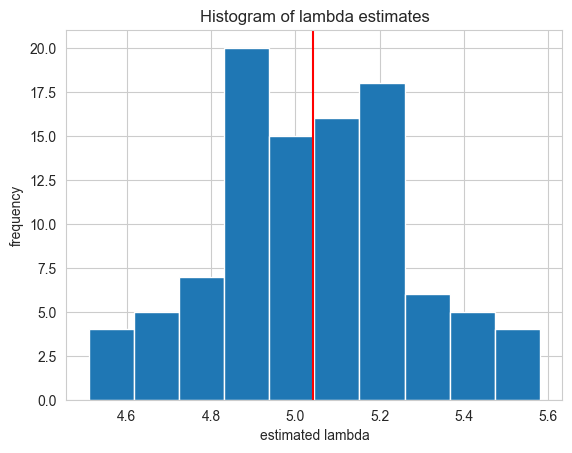

def get_errors(n: int) -> np.ndarray:
    true_lambda = 5
    return np.random.poisson(true_lambda, size=n)



In [6]:
from util_week_10 import get_errors
import numpy as np
import matplotlib.pyplot as plt

def estimate_lambda(data: np.ndarray) -> float:
    return float(np.mean(data))

def make_histogram():
  estimates = []
  for _ in range(100):
      sample = get_errors(100)
      estimates.append(estimate_lambda(sample))

  print(np.mean(estimates))

  plt.hist(estimates)
  plt.axvline(np.mean(estimates), color='red')
  plt.title("Histogram of lambda estimates")
  plt.xlabel("estimated lambda")
  plt.ylabel('frequency')
  plt.show()

n = 100
data = get_errors(n)
lambda_hat = estimate_lambda(data)
print(lambda_hat)

# estimator: the sample mean = function estimate_lambda
# estimate: the value of lambda_hat

make_histogram()

import inspect
print(inspect.getsource(get_errors))

## Exercise 2

A physicist repeatedly measures the voltage output from a device. Due to small random measurement errors, the recorded voltages vary slightly. The measured value could be modeled using a normal distribution, where the mean is the true voltage, and the variance of the normal distribution is the measurement variance. Function `get_measurements(n)` returns $n$ independent voltage measurements.

1. Write two functions that will estimate the mean and variance based on the observed measurements.
2. Generate a sample of $n$ measurements and compute mean and variance. What is the estimator, and the estimate here?
3. Repeat the estimation process on multiple data samples. Plot two histograms: one for mean and one for variance.
4. Is any estimator here biased? How does increasing sample size change the histograms?
5. Compare the results to the true values in `get_measurements()` function.

4.778185541950155
3.2766284763223994
3.3097257336589894


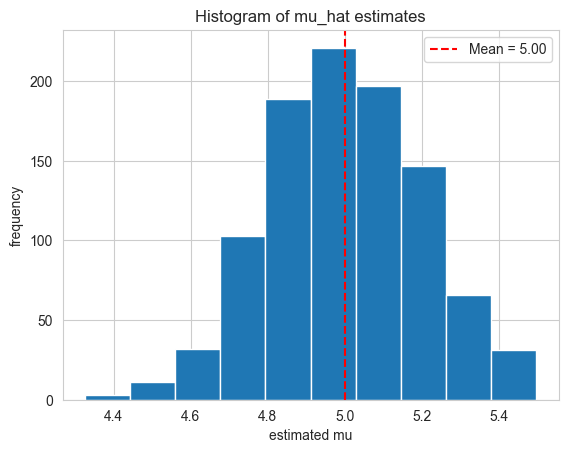

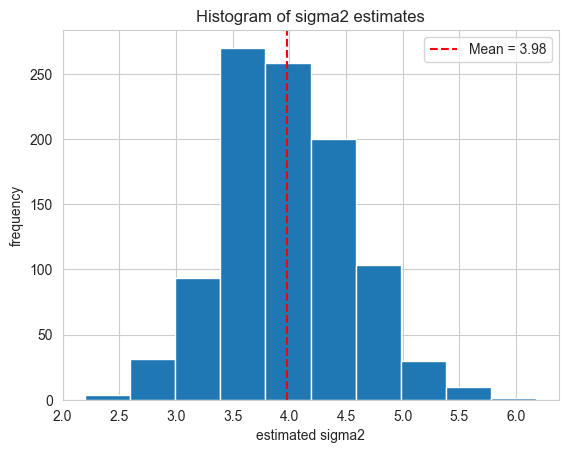

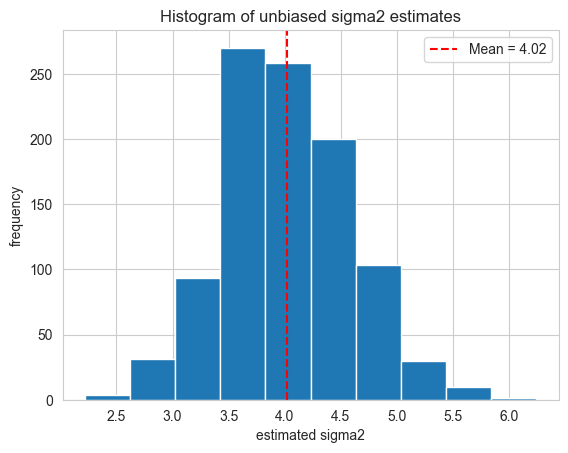

def get_measurements(n: int) -> np.ndarray:
    true_mu = 5.0
    true_sigma = 2.0
    return np.random.normal(true_mu, true_sigma, size=n)



In [15]:
from util_week_10 import get_measurements
import numpy as np
import matplotlib.pyplot as plt

def estimate_mu(data: np.ndarray):
    return np.mean(data)

def estimate_sigma2_mle(data: np.ndarray):
    mu_hat = np.mean(data)
    return np.mean((data - mu_hat)**2)

def estimate_sigma2_unbiased(data: np.ndarray):
    mu_hat = np.mean(data)
    return (np.sum((data - mu_hat)**2)) / (data.shape[0] - 1)

def plot_histogram(data, title: str, xlabel: str, ylabel: str = 'frequency'):
    plt.hist(data)
    plt.axvline(np.mean(data), color='red', linestyle='dashed', label=f'Mean = {np.mean(data):.2f}')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

def plot_many_repetitions(n: int = 100, repetitions: int = 1000):
    mu_estimates = []
    sigma2_estimates = []
    sigma2_unbiased_estimates = []

    for _ in range(repetitions):
        sample = get_measurements(n)
        mu_estimates.append(estimate_mu(sample))
        sigma2_estimates.append(estimate_sigma2_mle(sample))
        sigma2_unbiased_estimates.append(estimate_sigma2_unbiased(sample))

    plot_histogram(mu_estimates, 'Histogram of mu_hat estimates', 'estimated mu')
    plot_histogram(sigma2_estimates, 'Histogram of sigma2 estimates', 'estimated sigma2')
    plot_histogram(sigma2_unbiased_estimates, 'Histogram of unbiased sigma2 estimates', 'estimated sigma2')

n = 100
data = get_measurements(n)

mu_hat = estimate_mu(data)
print(mu_hat)
sigma2_hat = estimate_sigma2_mle(data)
print(sigma2_hat)
unbiased_sigma2_hat = estimate_sigma2_unbiased(data)
print(unbiased_sigma2_hat)

plot_many_repetitions()

import inspect
print(inspect.getsource(get_measurements))

## Exercise 3

Alice is modeling the number of customer support tickets that a company received per hour and believes that the tickets follow a Poisson distribution with unknown rate $\lambda$. The maximum likelihood estimate for $\lambda$ in a Poisson distribution is the sample mean.

1. Write a function `generate_tickets(n, true_lambda)` that returns $n$ observations from the Poisson distribution with given `true_lambda`.
2. Write a function to compute the estimate of $\lambda$.
3. Compute the estimate of $\lambda$ for sample sizes between 1 and 100 and plot the estimate of $\lambda$ as a function of n - what happens to the estimate as n grows?
4. Write a function to repeat the computation from 3 multiple times and plot the estimates together - what do you see?

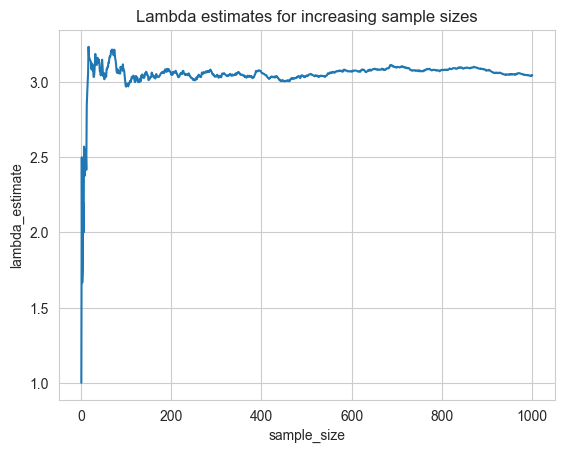

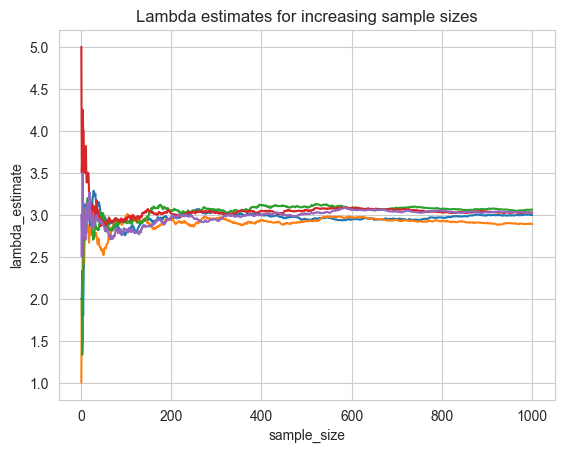

In [26]:
def generate_tickets(n: int, true_lambda: int = 3):
    return np.random.poisson(lam=true_lambda, size=n)

def estimate_lambda(data: np.ndarray):
    return np.mean(data)

def compute_estimates_for_range(sample_size_min: int = 1, sample_size_max: int = 100):

    data = generate_tickets(sample_size_max)
    lambda_estimates = [estimate_lambda(data[: i]) for i in range(sample_size_min, sample_size_max + 1)]

    # alternative: compute it on different data samples respecting the size:
    # lambda_estimates = []
    # for n in range(sample_size_min, sample_size_max + 1):
    #     data = generate_tickets(n)
    #     lambda_hat = estimate_lambda(data)
    #     lambda_estimates.append(lambda_hat)

    return lambda_estimates

def repeat_estimates_computation(sample_size_min: int = 1, sample_size_max: int = 1000, repetitions: int = 10):
    for _ in range(repetitions):
      lambda_estimates = compute_estimates_for_range(sample_size_min, sample_size_max)
      plt.plot(list(range(sample_size_min, sample_size_max + 1)), lambda_estimates)

    plt.title('Lambda estimates for increasing sample sizes')
    plt.xlabel('sample_size')
    plt.ylabel('lambda_estimate')
    plt.show()

lambda_estimates = compute_estimates_for_range(1, 1000)
plt.plot(list(range(1, 1001)), lambda_estimates) # it converges to true lambda
plt.title('Lambda estimates for increasing sample sizes')
plt.xlabel('sample_size')
plt.ylabel('lambda_estimate')
plt.show()

repeat_estimates_computation(1, 1000, 5) # they all converge to the same (true) value